# Lecture 3 — Line Charts & Slopegraphs
## Clutter is Your Enemy

> **Dataset:** CO2 Emissions by Country 2000-2022 [Our World in Data](https://ourworldindata.org/co2-emissions)

> **Source of figures:** Knaflic, C. N. (2015). *Storytelling with data*. Wiley.



---
## Opening: Model Answer Review 


## Design Principles - Part I: Lines & Slopegraphs


### Line charts imply continuity

> 💡 **A line chart physically connects every data point. That connection implies the thing between the points is real — that values are continuous, not discrete. The line says: this is a trend. So only use a line when it IS a trend**

| Use a line | Use a bar instead |
|---|---|
| Time series (months, years, days) | Comparing unordered categories |
| Continuous process | Discrete groups (regions, products) |
| Showing a trajectory | Showing a snapshot comparison |


**[ FIGURE 2.8 — p.46 ]**

*Line graph variants: single series, two series, multiple series (‼️the spaghetti risk‼️)*


> 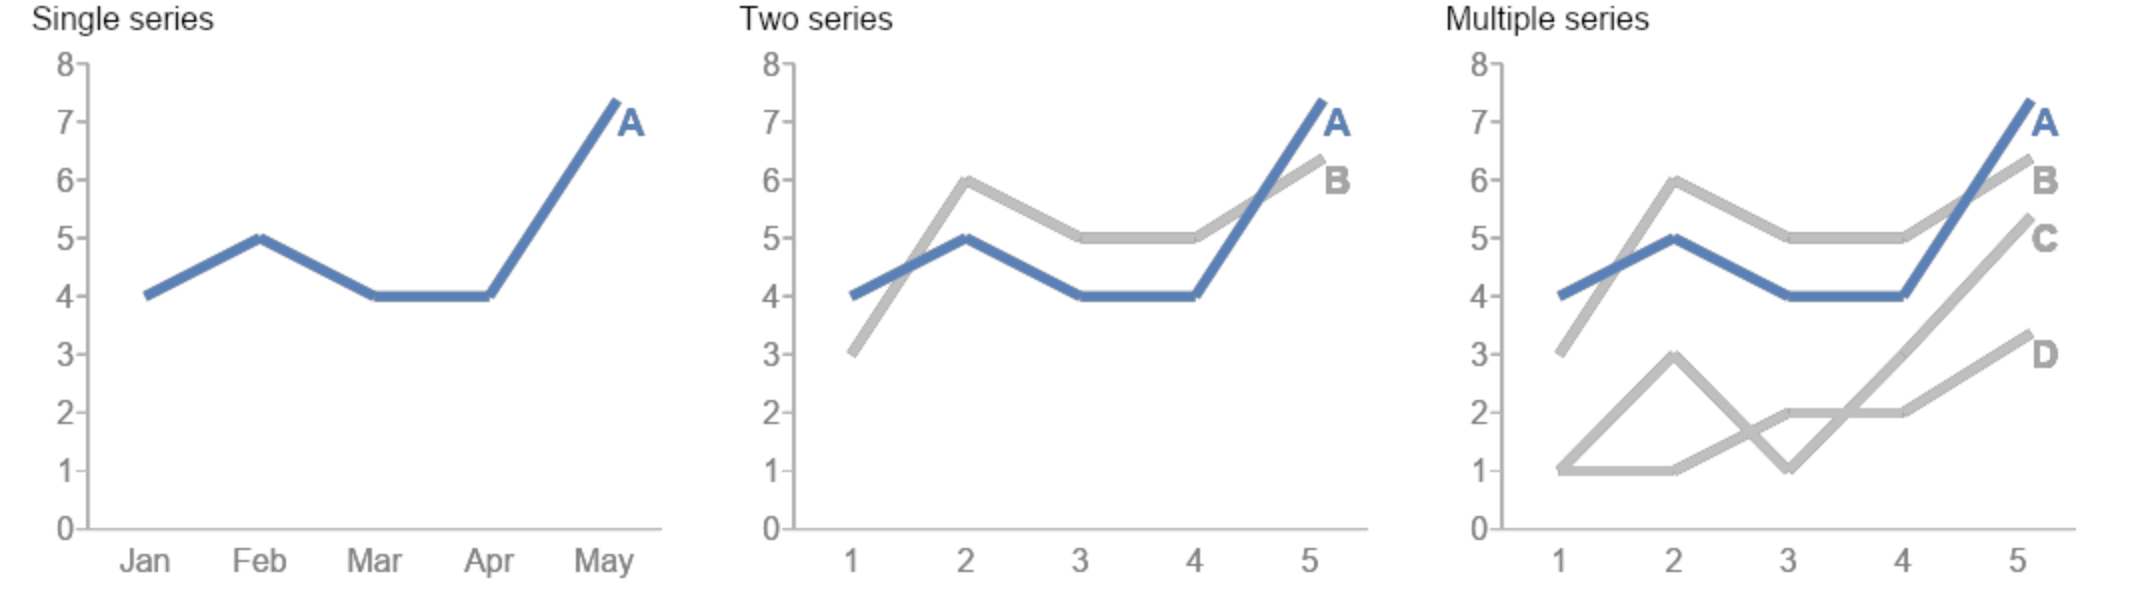 


### Slopegraph — two points, maximum clarity

> 💡 **When you have exactly two time points to compare, a slopegraph is one of the most powerful charts available. The slope of each line IS the story — you do not need to explain rate of change. The eye reads it instantly**


*Slopegraph: employee survey results 2014 vs 2015 — all categories shown [ FIGURE 2.10 — p.48 ]*


> 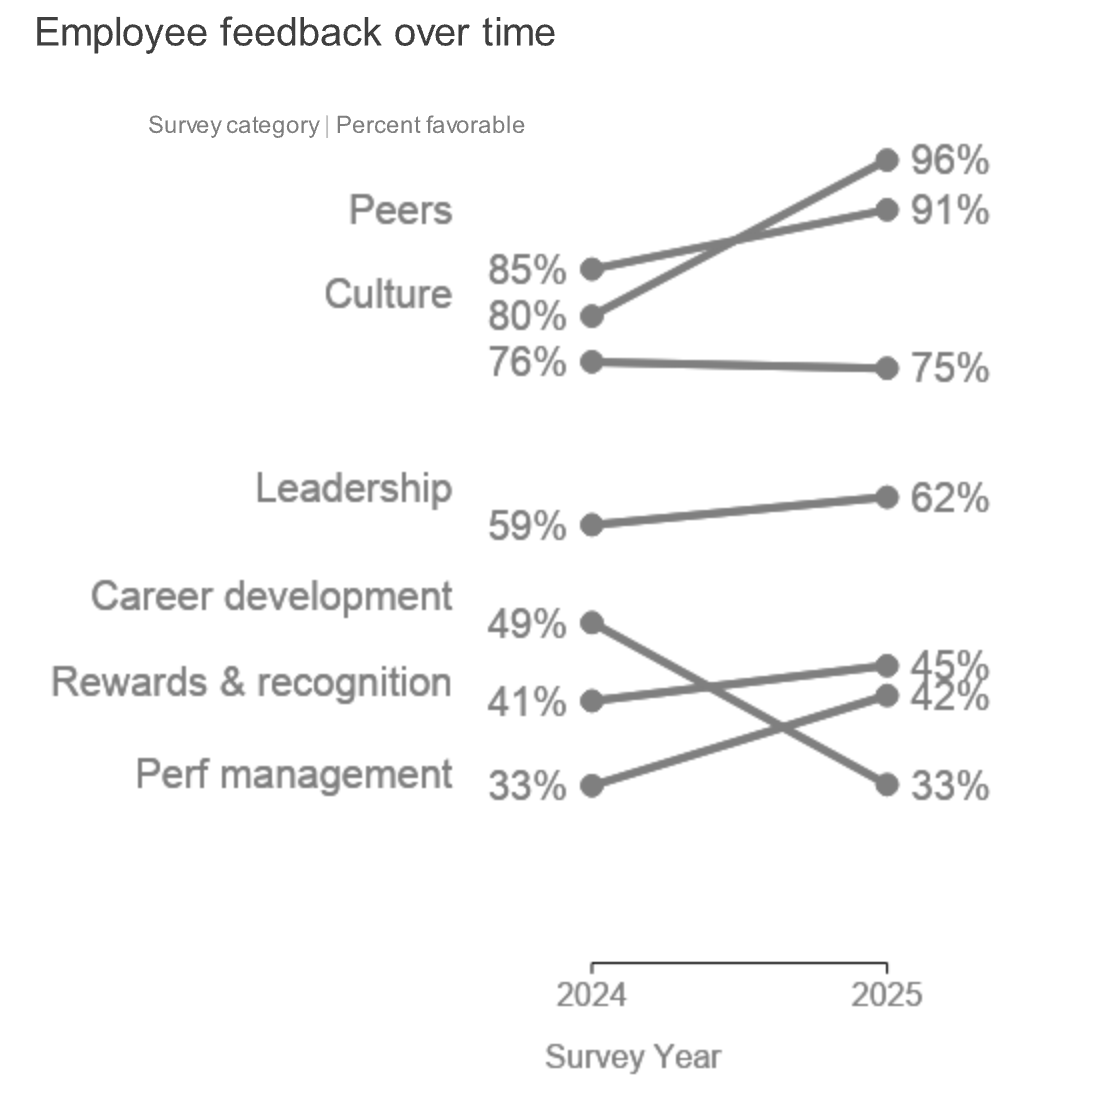 


*Modified slopegraph: one declining category highlighted; everything else grey [ FIGURE 2.11 — p.49 ]*

> 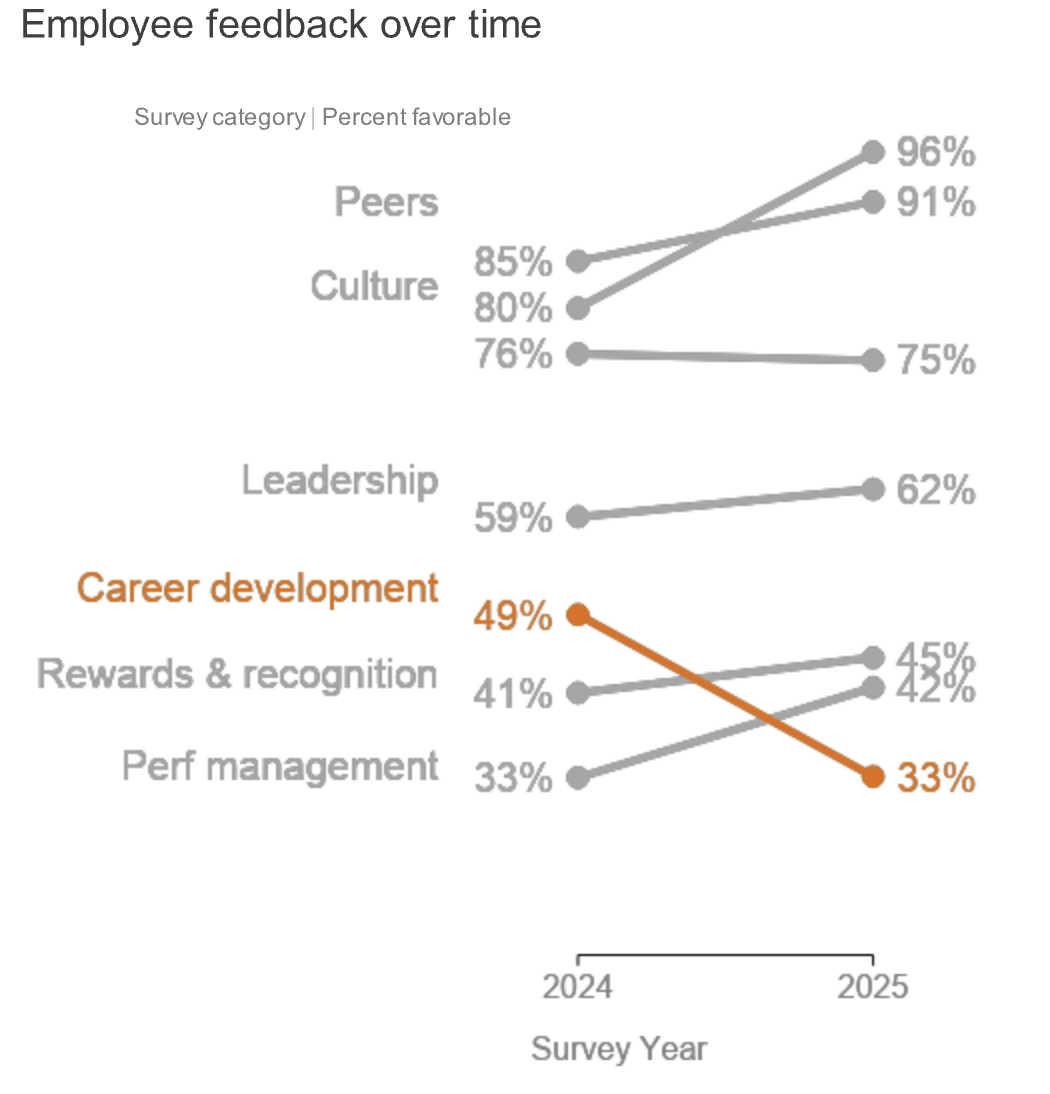 



## Design Principles - Part II: Clutter


### Cognitive load

> 💡 **Every element you add to a chart requires the viewer's brain to process it. This is cognitive load. Clutter is anything that consumes that brain power without adding information. Every non-data element is a candidate for removal**


*Original ticket volume chart — the cluttered 'before' used in  Lecture 2 [ FIGURE 3.17 — p.91 ]*

> 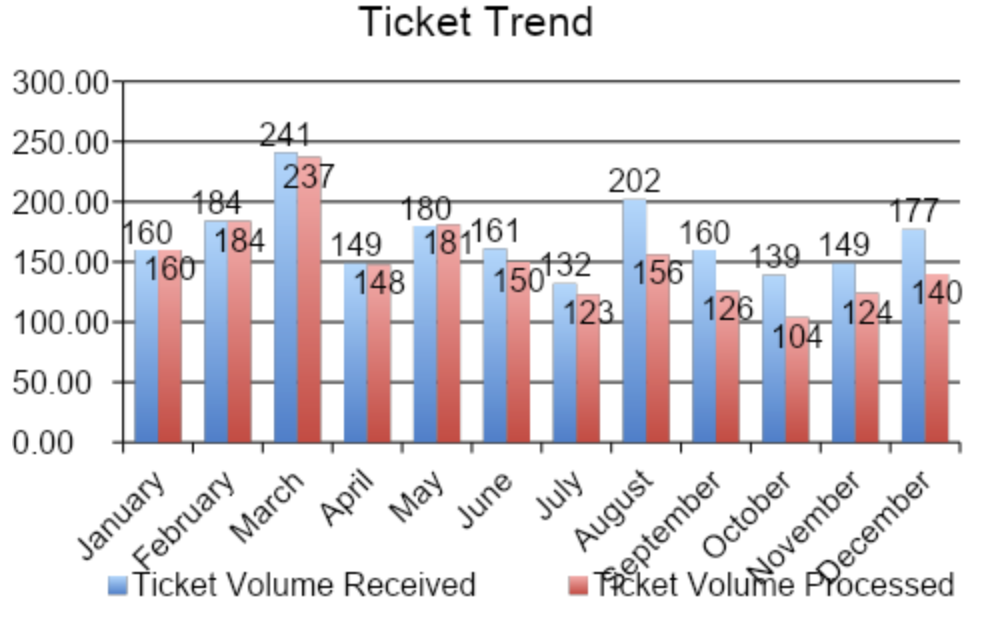 



### 💡 The 6️⃣ Gestalt principles

- Gestalt principles are a set of rules describing how the human visual system organises elements into perceived wholes

- Developed in the early 20th century by a group of German psychologists Max Wertheimer, Kurt Koffka, Wolfgang Köhler — working within the Gestalt school of psychology

- The word Gestalt is German for "form" or "shape"


**1. Proximity: elements placed close together are perceived as belonging to the same group [ FIGURE 3.1 — p.75 ]**

> 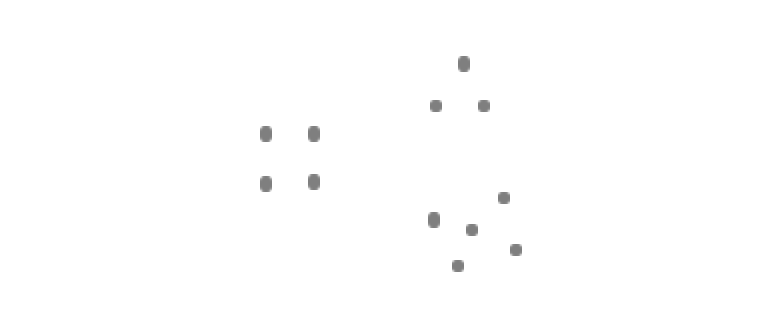 

**2. Similarity: elements that share colour, shape, or size are perceived as related [ FIGURE 3.3 — p.76 ]**

> 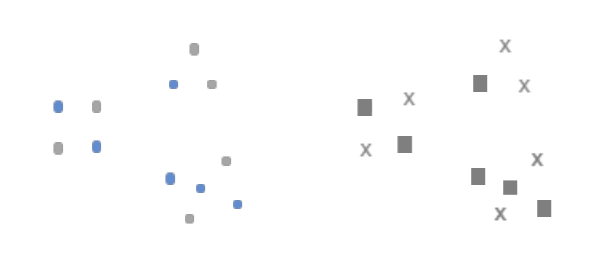 


**3. Enclosure: elements within a shared boundary or shaded region are perceived as a group [ FIGURE 3.5 — p.77 ]**

> 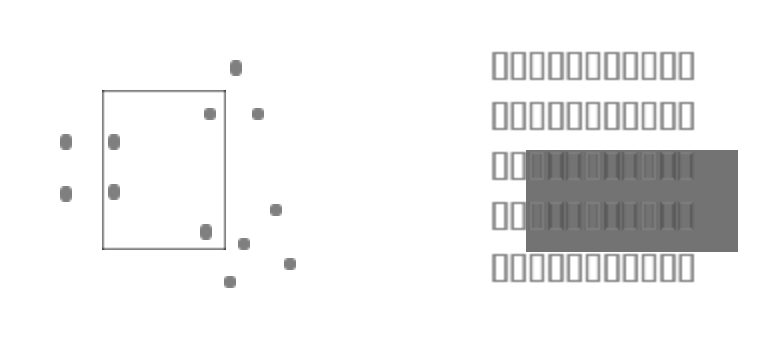 


**4. Closure: the mind automatically completes incomplete shapes; full borders are rarely needed [ FIGURE 3.7 — p.78 ]**

> 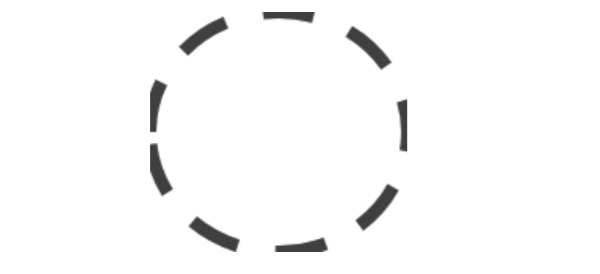 


**5.Continuity: the eye follows the smoothest path, so gridlines and axis lines often add more friction than value [FIGURE 3.9 — p.79 ]**

> 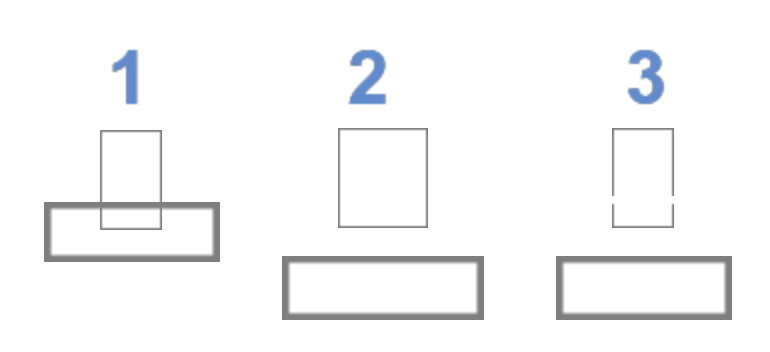 


**6. Connection: elements joined by a line are seen as related, making it the strongest grouping cue of all — overrides proximity and similarity [FIGURE 3.11 — p.80 ]**

> 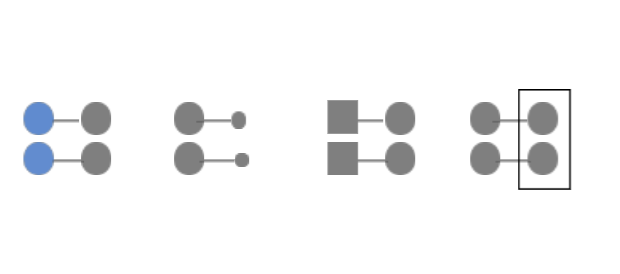 





**Practical hit list — elements to remove by default:**

| Remove | Why |
|---|---|
| Chart border | Gestalt closure — the eye sees the chart edge without it |
| Gridlines (or lighten to #EEEEEE) | Data should stand out, not the grid |
| Data markers on every point | Adds cognitive load with no new information |
| Legend when you can label directly | Legend forces eye movement; labels use proximity |
| Trailing zeros (0.00 → 0) | Numbers look complicated; trailing zeros add nothing |
| Rotated/diagonal text | 52% slower to read; use horizontal bars instead |
| Background colour | Light elements on dark = harder to read |


**Before(halfway-done)/after: the fully decluttered ticket volume chart through applying the Gestalt principles [ FIGURE 3.24 — p.98 ]**

> 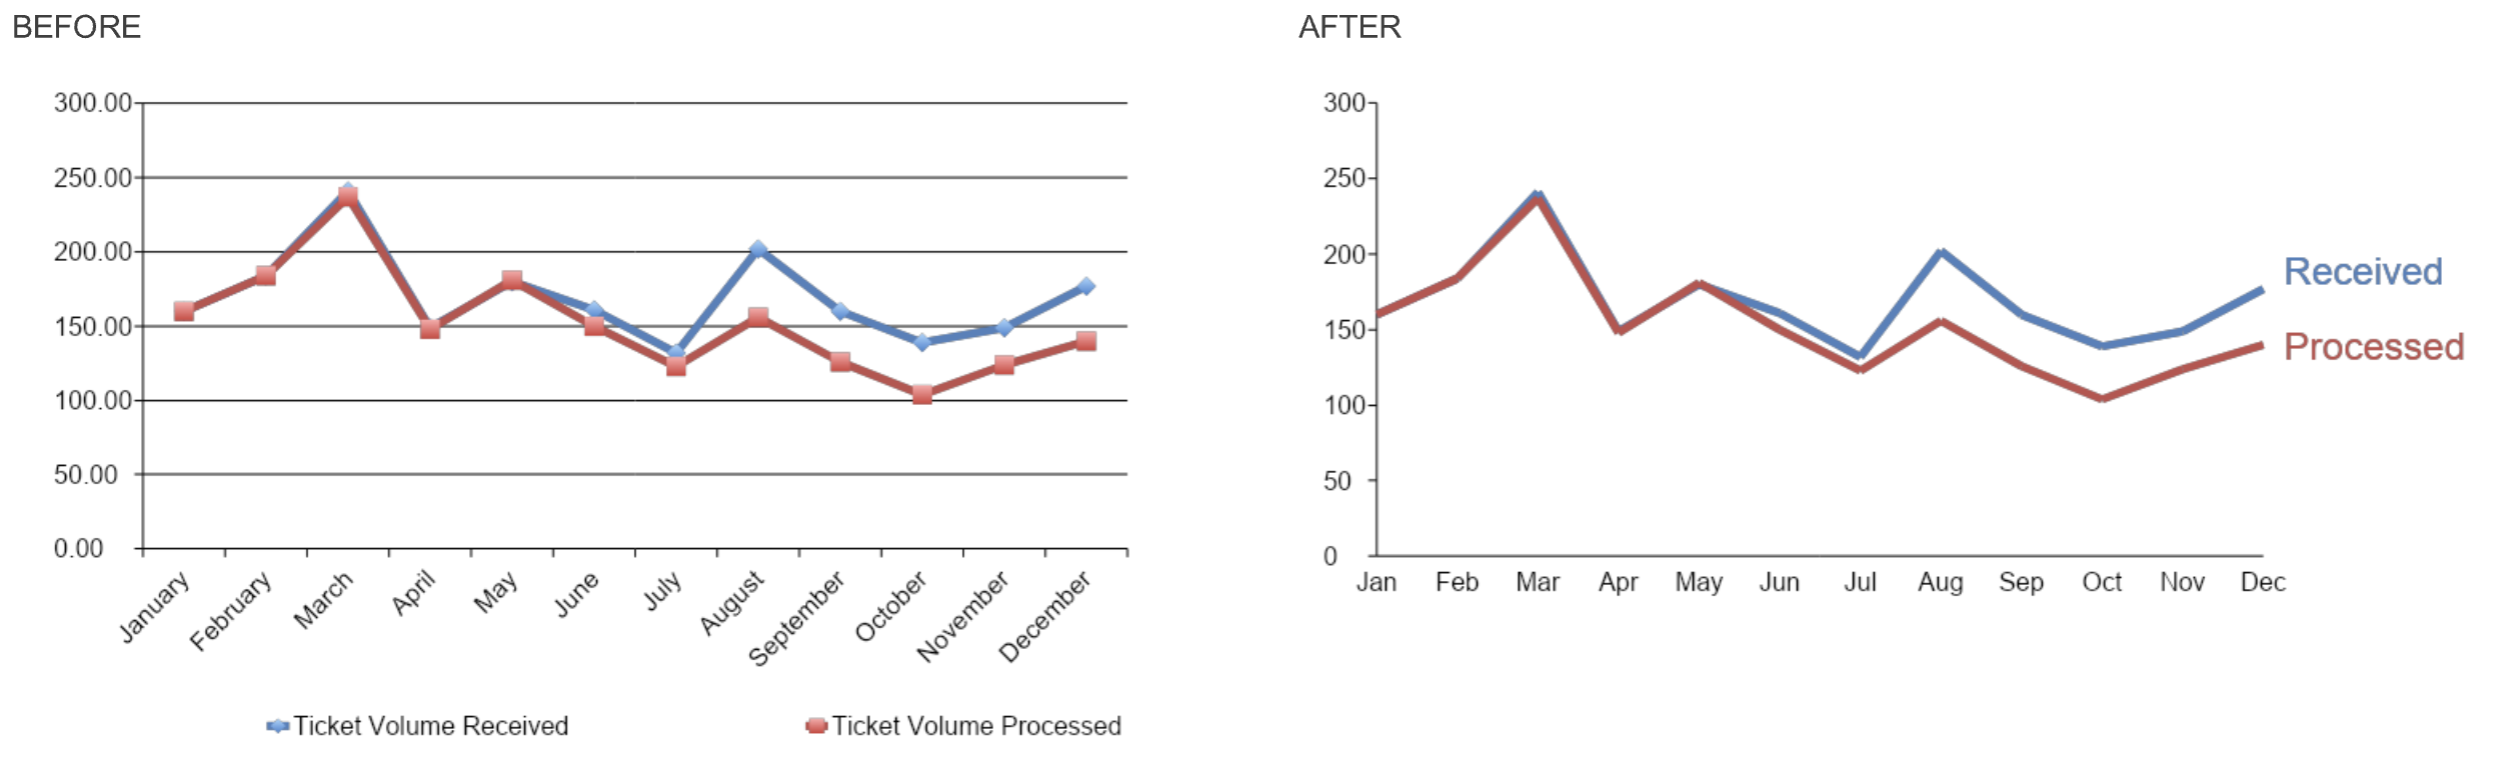 


---
## Let's Code Some Examples 💻 


In [ ]:
import pandas as pd
import plotly.express as px


df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


### Example 1 — Basic line chart: Clutter removal step by step

In [ ]:

usa = df.loc[df['Country'] == 'United States']

fig = px.line(usa, x='Year', y='CO2_Mt', title='CO2 Emissions over time')
fig.show()

In [ ]:
# Let's apply the principles

fig = px.line(usa, x='Year', y='CO2_Mt',
              labels={'CO2_Mt': 'CO2 Emissions (Mt)', 'Year': ''},
              color_discrete_sequence=['#2E75B6'])

fig.update_layout(
    title='US CO2 emissions have fallen 20% since 2005 — but the pace has slowed',
    # Gestalt closure: white background removes the need for a chart border
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    # Gridlines: make very light so data stands out; don't compete with the line
    yaxis=dict(gridcolor='#EEEEEE', gridwidth=1, title='CO2 (Mt)'),
    # x-axis: remove grid entirely (years are readable, grid adds nothing)
    xaxis=dict(showgrid=False, title=''),
    margin=dict(l=60, r=40, t=55, b=40)
)

fig.update_traces(
    line=dict(width=2.5),   # slightly thicker line = more prominent than axis lines
    mode='lines'             # no markers needed on a dense time series
)


fig.show()


### Example 2 — Multi-series: the spaghetti problem and how to fix it

In [ ]:

fig = px.line(df, x='Year', y='CO2_Mt', color='Country',
              title='CO2 Emissions by Country', height=500)

fig.show()

In [ ]:
# Let's apply the principles

highlight = 'China'

# Build colour map: highlight in blue, everything else grey
color_map = {c: '#2E75B6' if c == highlight else '#DDDDDD' for c in df['Country'].unique()}

fig = px.line(df, x='Year', y='CO2_Mt', color='Country',
              color_discrete_map=color_map,
              labels={'CO2_Mt': 'CO2 Emissions (Mt)', 'Year': ''})

fig.update_traces(
    line=dict(width=1.5),   # default: thin for context countries
    showlegend=False      # direct label replaces legend (Gestalt proximity)
)

# Override highlighted country: thicker line
fig.update_traces(
    line=dict(width=3),
    selector=dict(name=highlight)
)

# Direct label at end of highlighted line
last = df.loc[(df['Country'] == highlight) & (df['Year'] == df['Year'].max())]

fig.add_annotation(
    x=last['Year'].values[0], y=last['CO2_Mt'].values[0],
    text=f'<b>{highlight}</b>', showarrow=False,
    xanchor='left', xshift=6,
    font=dict(color='#2E75B6', size=12, family='Arial')
)

fig.update_layout(
    title="China's CO2 emissions tripled 2000–2022 — no other country comes close",
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(gridcolor='#EEEEEE', title='CO2 Emissions (Mt)'),
    xaxis=dict(showgrid=False, title=''),
    margin=dict(l=60, r=80, t=55, b=40)
)

fig.show()

### Example 3 — Slopegraph: comparing two points in time

In [ ]:

two_years = df.loc[df['Year'].isin([2000, 2022])].copy()

two_years['Year'] = two_years['Year'].astype(str)

fig = px.bar(two_years, x='Country', y='CO2_Mt', color='Year',
             barmode='group', title='CO2 Emissions 2000 vs 2022', height=500)
fig.show()

In [ ]:
# Let's apply the principles

#prep data
selected = ['China', 'India', 'United States', 'Germany','Russia', 'South Korea']
sg = df.loc[df['Country'].isin(selected) & df['Year'].isin([2000, 2022])].copy()

changes = sg.groupby('Country')['CO2_Mt'].agg(['first', 'last'])
color_map = {c: 'red' if row['last'] > row['first'] else 'green' for c, row in changes.iterrows()}

fig = px.line(sg.sort_values('Year'), x='Year', y='CO2_Mt', color='Country',
              color_discrete_map=color_map, markers=True,
              labels={'CO2_Mt': '', 'Year': ''})

for country in selected:
    d = sg.loc[sg['Country'] == country].sort_values('Year')
    fig.update_traces(
        selector=dict(name=country),
        mode='lines+markers+text',
        text=[f'{d["CO2_Mt"].iloc[0]:.0f}', f'{country}<br>{d["CO2_Mt"].iloc[1]:.0f}'],
        textposition=['middle left', 'middle right'],
        textfont=dict(size=10, color=color_map[country], family='Arial'),
        showlegend=False
    )

fig.update_layout(
    title='Blue = increased since 2000 | Orange = decreased | China and India dwarf all others',
    xaxis=dict(tickvals=[2000, 2022], ticktext=['2000', '2022'],
               showgrid=False, range=[1995, 2028]),
    yaxis=dict(showgrid=False, showticklabels=False, title=''),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    margin=dict(l=80, r=120, t=55, b=40),
    height=800, width=1000
)

fig.show()

In [ ]:
sg

In [ ]:
changes

---
## Class Exercise 💪 💻


**Remember:**
- No spaghetti — if you show multiple lines, grey everything and highlight one
- Remove chart borders, heavy gridlines, rotating text
- Label directly; avoid legends where possible
- Insight title
